### Lab 1: Suspicious Transaction Detection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
df1 = pd.read_csv("Customer_Master.csv")
df2 = pd.read_csv("transactions.csv")

#### View the info of the read data

In [3]:
df1.head()

,customer_id,age_group,home_location,credit_score,account_age_years,account_type,avg_monthly_income,mobile_banking_user,primary_device,primary_os,primary_browser,avg_transaction_amount,transaction_frequency,employment_status,preferred_transaction_types,international_activity,risk_score
0,1,26-35,Palpa,714,13,Savings,55580.82584,True,iPad,iOS,Samsung Internet,6498.703229,22,Self-employed,"['Loan Payment', 'Internet Bill Payment', 'Wat...",True,30
1,2,26-35,Kathmandu,607,7,Savings,34640.46996,True,Android Tablet,Android,Chrome,3946.766234,6,Employed,"['Loan Payment', 'Branch Deposit', 'QR Payment...",True,33
2,3,56-65,Mustang,589,10,Savings,37965.86776,True,Android Tablet,Android,Edge,13286.477130,27,Employed,"['Branch Deposit', 'Electricity Bill Payment',...",False,8
3,4,46-55,Biratnagar,609,8,Savings,22131.66118,True,iPhone,iOS,Safari,5199.307947,19,Self-employed,"['Insurance Premium Payment', 'Branch Withdraw...",False,18
4,5,26-35,Butwal,706,7,Current,107904.58120,True,iPhone,iOS,Chrome,19884.694310,26,Employed,"['Mobile Recharge', 'Internet Bill Payment', '...",True,33


In [4]:
df2.head()

,transaction_id,customer_id,transaction_date,transaction_type,amount,location,ip_address,device,os,browser,...,credit_score,account_age_years,account_type,avg_monthly_income,mobile_banking_user,transaction_frequency,employment_status,international_activity,risk_score,is_suspicious
0,TXN20241124104326,727,11/24/2024 15:29,Inward Remittance,13925.72,Nawalparasi,103.92.86.139,NaN,NaN,NaN,...,673,1,Current,65911.89284,True,20,Employed,False,24,False
1,TXN20241204130277,539,12/04/2024 5:26,ATM Withdrawal,25037.35,Kaski,27.201.191.54,NaN,NaN,NaN,...,666,11,Current,75126.72458,True,3,Employed,False,19,False
2,TXN20240813940494,84,8/13/2024 22:42,Cheque Deposit,6677.66,Pokhara,27.231.166.66,NaN,NaN,NaN,...,474,5,Savings,33904.26167,True,14,Employed,False,42,False
3,TXN20240213270855,660,2/13/2024 10:51,School Fee Payment,16071.37,Biratnagar,43.122.204.45,NaN,NaN,NaN,...,680,6,Savings,51961.55841,False,8,Employed,False,26,False
4,TXN20240615309580,398,6/15/2024 9:41,POS Transaction,17196.84,Pokhara,103.67.183.49,NaN,NaN,NaN,...,582,9,Current,122082.36450,True,16,Self-employed,False,1,False


### Merge the datasets using Left Join
#### We take df2 as primary dataset  to perform join

In [5]:
df = df2.merge(df1, on='customer_id', how='left', suffixes=('_txn', '_cust'))

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103500 entries, 0 to 103499
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   transaction_id               103500 non-null  object 
 1   customer_id                  103500 non-null  int64  
 2   transaction_date             103500 non-null  object 
 3   transaction_type             103500 non-null  object 
 4   amount                       103500 non-null  float64
 5   location                     103500 non-null  object 
 6   ip_address                   103500 non-null  object 
 7   device                       23509 non-null   object 
 8   os                           23537 non-null   object 
 9   browser                      23533 non-null   object 
 10  attempt_sequence             103500 non-null  int64  
 11  time_of_day                  103500 non-null  object 
 12  transaction_velocity         103500 non-null  int64  
 13 

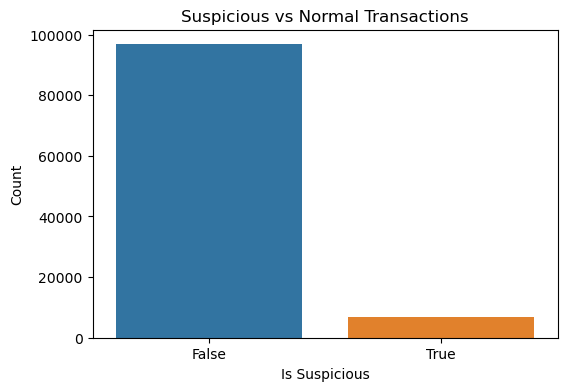

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='is_suspicious')
plt.title("Suspicious vs Normal Transactions")
plt.xlabel("Is Suspicious")
plt.ylabel("Count")
plt.show()

#### The figure indicates that only a small proportion of transactions are classified as suspicious. Approximately 2,000 transactions fall into the suspicious category, while the vast majority are non-suspicious. This distribution suggests that, overall, the transaction environment is largely safe, with relatively few instances of potentially fraudulent activity.

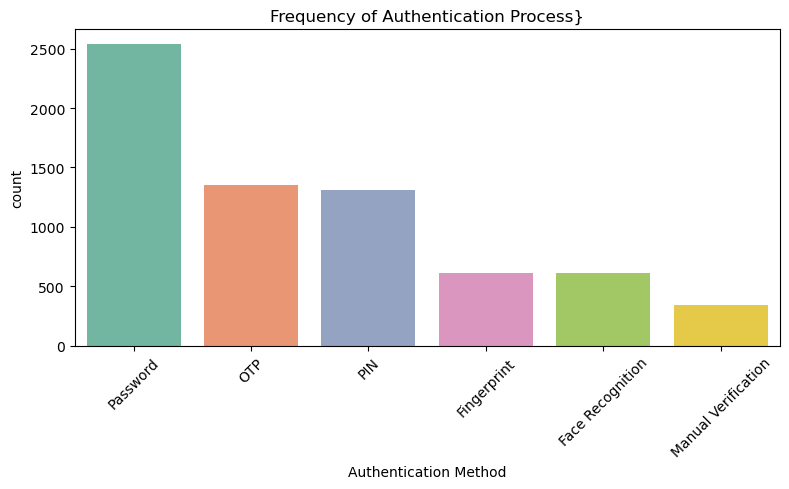

In [8]:
suspicious = df[df['is_suspicious'] == True]

plt.figure(figsize=(8,5))
sns.countplot(data=suspicious, x='auth_method', palette='Set2', order=suspicious['auth_method'].value_counts().index)
plt.title('Frequency of Authentication Process}')
plt.xticks(rotation=45)
plt.xlabel("Authentication Method")
plt.tight_layout()
plt.show()

#### The plot illustrates that the majority of transaction authentications are performed using passwords, followed by OTP and PIN-based methods. Manual verification is used least frequently among all authentication mechanisms. The OTP and PIN are almost identical with slight difference.

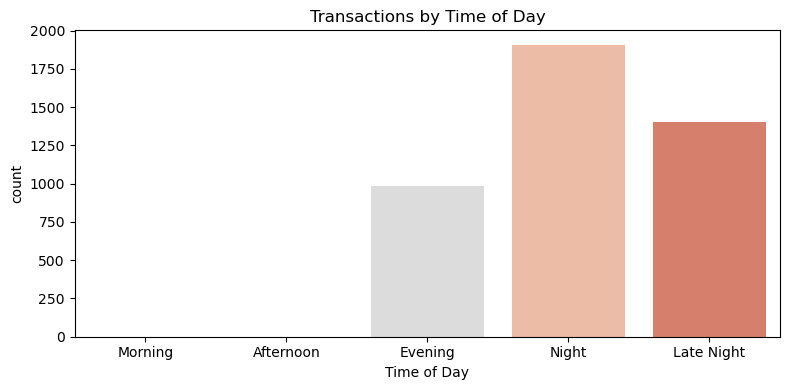

In [9]:
time_order = ['Morning', 'Afternoon', 'Evening', 'Night', 'Late Night']
plt.figure(figsize=(8,4))
sns.countplot(data=suspicious, x='time_of_day', palette='coolwarm', order=time_order)
plt.title("Transactions by Time of Day")
plt.xlabel("Time of Day")
plt.tight_layout()
plt.show()

#### The figure indicates that most transactions occur during the night, late night, and evening periods, while transaction activity is minimal during the afternoon and morning.

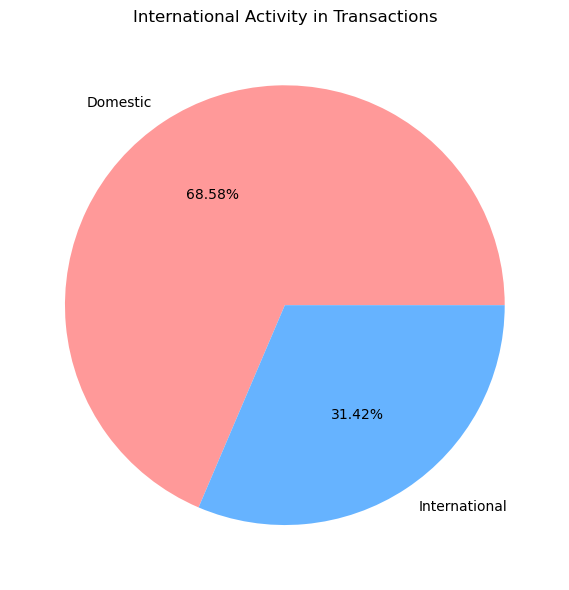

In [10]:
plt.figure(figsize=(6,6))
suspicious['international_activity_txn'].value_counts().plot.pie(autopct='%1.2f%%', 
labels=['Domestic', 'International'], colors=['#ff9999','#66b3ff'])
plt.title("International Activity in Transactions")
plt.ylabel("")
plt.tight_layout()
plt.show()

#### The figure shows that most of the transactions completed are done domestically (68.58%) and the rest are done internationally (31.42%).

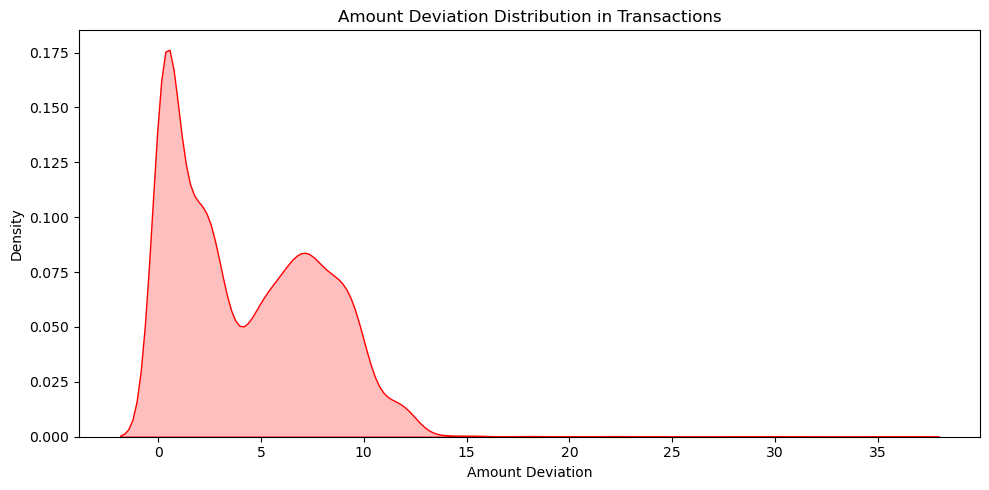

In [11]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=suspicious, x='amount_deviation', shade=True, color='red')
plt.title("Amount Deviation Distribution in Transactions")
plt.xlabel('Amount Deviation')
plt.tight_layout()
plt.show()

#### The figure illustrates that transaction amount deviation is inversely related to transaction density: higher deviations correspond to lower density, and lower deviations correspond to higher transaction density. The highest density, approximately 0.175, occurs at a very low amount deviation of around 0.18, while deviations above 14 have no observed density. Additionally, there appears to be a dip in density between amount deviations of roughly 0.18 to 4.5, where the density decreases from 0.178 to 0.050.

### Preprocessing

#### Filling null values with Unknown

In [12]:
fill_dict = {
    'primary_device': 'Unknown',
    'primary_os': 'Unknown',
    'primary_browser': 'Unknown',
    'device': 'Unknown',
    'os': 'Unknown',
    'browser': 'Unknown'
}

In [13]:
df.fillna(fill_dict, inplace=True)

#### Encoding non-numerical columns

In [14]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import Binarizer
from sklearn.model_selection import train_test_split

In [15]:
label_cols = [
    'home_location_txn', 'transaction_type', 'location', 'os', 'device', 'browser',
    'time_of_day', 'primary_os', 'primary_device', 'primary_browser','age_group_txn','age_group_cust'
]

for col in label_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
    else:
        print(f"Column {col} not found in DataFrame")

In [16]:
if 'status' in df.columns:
    df['status'] = (df['status'] != 'Success').astype(int)

In [17]:
onehot_cols = [
    'account_type_txn',
    'employment_status_txn',
    'auth_method',
    'account_type_cust',
    'employment_status_cust'
]

In [18]:
ohe = OneHotEncoder(drop='first', sparse_output=False)

encoded_array = ohe.fit_transform(df[onehot_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(onehot_cols),
    index=df.index
)

df = pd.concat([df.drop(columns=onehot_cols), encoded_df], axis=1)

In [19]:
separate_cols = [
    'transaction_id', 'transaction_date', 'ip_address',
    'age_group_txn', 'age_group_cust', 'preferred_transaction_types'
]

In [20]:
txn_str = df['transaction_id'].str.replace('TXN', '')

df['txn_year'] = txn_str.str[0:4].astype(int)
df['txn_month'] = txn_str.str[4:6].astype(int)
df['txn_day'] = txn_str.str[6:8].astype(int)
df['txn_hour'] = txn_str.str[8:10].astype(int)
df['txn_minute'] = txn_str.str[10:12].astype(int)
df['txn_second'] = txn_str.str[12:14].astype(int)

#### Dropping encoded columns

In [21]:
df.drop('transaction_id', axis=1, inplace=True)

In [22]:
df.drop('transaction_date', axis=1, inplace=True)

In [23]:
import ipaddress

def ip_to_int(ip):
    try:
        return int(ipaddress.IPv4Address(ip))
    except:
        return 0  

df['ip_address_numeric'] = df['ip_address'].apply(ip_to_int)

In [24]:
import ast

df['preferred_transaction_types'] = 
df['preferred_transaction_types'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)


In [25]:
df['preferred_transaction_types']

0         [Airline Ticket Payment, Inward Remittance, Wa...
1         [ATM Withdrawal, Wallet Load - Khalti, Outward...
2         [Mobile Recharge, Mobile Banking Transfer, Hot...
3         [POS Transaction, Cheque Payment, Loan Payment...
4         [Airline Ticket Payment, POS Transaction, Scho...
                                ...                        
103495    [Electricity Bill Payment, Mobile Recharge, PO...
103496    [Interest Credit, Loan Payment, Mobile Banking...
103497    [Interest Credit, Loan Payment, Mobile Banking...
103498    [QR Payment, ATM Withdrawal, Inward Remittance...
103499    [QR Payment, ATM Withdrawal, Inward Remittance...
Name: preferred_transaction_types, Length: 103500, dtype: object

In [26]:
all_types = set()
df['preferred_transaction_types'].apply(lambda x: all_types.update(x))

for t_type in all_types:
    df[f'pref_txn_{t_type.replace(" ", "_")}'] = df['preferred_transaction_types'].apply(lambda x: 1 if t_type in x else 0)

df.drop('preferred_transaction_types', axis=1, inplace=True)

In [27]:
df.drop('home_location_cust', axis=1, inplace=True)

In [28]:
df.drop('ip_address', axis=1, inplace=True)

### Model Training

#### Now lets train the data to predict the suspicion using RandomForestClassifier

In [29]:
y = df['is_suspicious']

X = df.drop('is_suspicious', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


                    feature  importance
11         amount_deviation    0.344115
9      transaction_velocity    0.283006
7          attempt_sequence    0.099164
2                    amount    0.080004
10                   status    0.041960
58       ip_address_numeric    0.024681
1          transaction_type    0.015620
6                   browser    0.012801
4                    device    0.011222
5                        os    0.010656
3                  location    0.008071
29   avg_transaction_amount    0.005560
27               primary_os    0.005193
26           primary_device    0.003935
24  avg_monthly_income_cust    0.003807
8               time_of_day    0.003692
44     auth_method_Password    0.003238
16   avg_monthly_income_txn    0.003204
57               txn_second    0.002356
28          primary_browser    0.002289


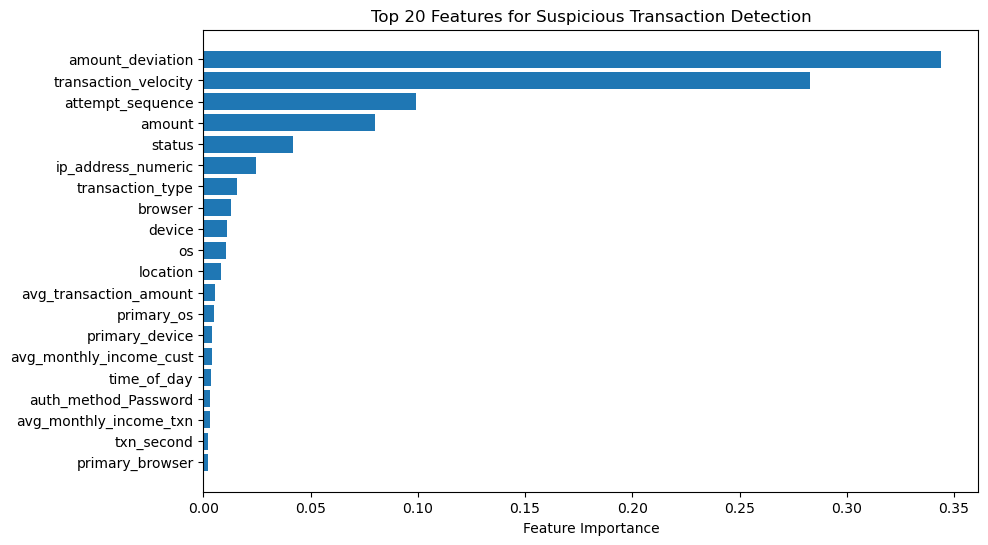

In [42]:
feat_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
})

feat_importances = feat_importances.sort_values(by='importance', ascending=False)

print(feat_importances.head(20))

plt.figure(figsize=(10,6))
plt.barh(feat_importances['feature'].head(20)[::-1], feat_importances['importance'].head(20)[::-1])
plt.xlabel('Feature Importance')
plt.title('Top 20 Features for Suspicious Transaction Detection')
plt.show()

#### The above feature importance bargraph shows that the most important feature values which are amount_deviation and transaction_velocity followed by attempt_sequence, amount and status. The rest of the features have very low significance

#### Now lets try another algorithm called IsolationForest

In [32]:
from sklearn.ensemble import IsolationForest

In [33]:
iso = IsolationForest(
    n_estimators=300,
    contamination=y.mean(), 
    random_state=42,
    n_jobs=-1
)

iso.fit(X_train)

,n_estimators,300
,max_samples,'auto'
,contamination,0.06532367149758454
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


In [34]:
iso_pred = iso.predict(X_test)
iso_pred = np.where(iso_pred == -1, 1, 0)

anomaly_scores = iso.decision_function(X_test)

In [35]:
from sklearn.metrics import accuracy_score, classification_report

print("Isolation Forest Accuracy:", accuracy_score(y_test, iso_pred))
print("\nClassification Report:\n", classification_report(y_test, iso_pred))

Isolation Forest Accuracy: 0.8972463768115942

Classification Report:
               precision    recall  f1-score   support

       False       0.94      0.95      0.95     19310
        True       0.22      0.21      0.22      1390

    accuracy                           0.90     20700
   macro avg       0.58      0.58      0.58     20700
weighted avg       0.90      0.90      0.90     20700



#### The above report shows that the trained model is predicting the 'is_suspicious' properly. Now lets find all the suspicious activities from the data using the IsolationForest algorithm

In [36]:
df_iso = X_test.copy()
df_iso["prediction"] = iso_pred
df_iso["anomaly_score"] = anomaly_scores

In [37]:
df_suspicious = df_iso[df_iso["prediction"] == 1]
df_suspicious.count()

customer_id                           1333
transaction_type                      1333
amount                                1333
location                              1333
device                                1333
                                      ... 
pref_txn_Interest_Credit              1333
pref_txn_Electricity_Bill_Payment     1333
pref_txn_Insurance_Premium_Payment    1333
prediction                            1333
anomaly_score                         1333
Length: 86, dtype: int64

#### It seems that a total of 1329 transactions are suspicious

In [38]:
df_most_suspicious = df_suspicious.sort_values("anomaly_score").head(10)
df_most_suspicious

,customer_id,transaction_type,amount,location,device,os,browser,attempt_sequence,time_of_day,transaction_velocity,...,pref_txn_Mobile_Recharge,pref_txn_Mobile_Banking_Bill_Payment,pref_txn_Internet_Bill_Payment,pref_txn_Loan_Payment,pref_txn_Inward_Remittance,pref_txn_Interest_Credit,pref_txn_Electricity_Bill_Payment,pref_txn_Insurance_Premium_Payment,prediction,anomaly_score
2683,905,23,272307.03,32,2,4,6,5,1,15,...,0,0,0,0,0,0,0,1,1,-0.097172
43579,905,19,425709.88,39,6,4,3,4,3,2,...,0,0,0,0,0,0,0,1,1,-0.081157
100482,829,23,539983.24,42,5,4,0,1,4,9,...,0,0,1,0,1,1,0,0,1,-0.074179
78400,820,22,83163.73,28,3,0,6,1,1,4,...,0,1,1,0,0,0,1,0,1,-0.072406
101634,905,15,20113.06,45,1,4,0,2,3,11,...,0,0,0,0,0,0,0,1,1,-0.068011
100855,385,23,435083.05,25,6,4,3,1,4,7,...,0,0,1,1,0,0,0,0,1,-0.066518
65168,905,9,323341.08,42,4,2,7,1,0,1,...,0,0,0,0,0,0,0,1,1,-0.065101
29333,62,10,90670.82,41,4,2,7,1,0,14,...,1,0,0,0,1,0,0,0,1,-0.063557
100480,829,15,293476.63,14,5,4,0,1,4,7,...,0,0,1,0,1,1,0,0,1,-0.063455
21849,905,15,63318.49,6,6,4,3,1,0,3,...,0,0,0,0,0,0,0,1,1,-0.059061


In [39]:
most_suspicious_account = (
    df_suspicious.groupby("customer_id")["anomaly_score"]
    .mean()
    .sort_values()
    .index[0]
)
most_suspicious_account

905

In [40]:
account_scores = (
    df_suspicious.groupby("customer_id")["anomaly_score"]
    .mean()
    .sort_values()
)
top10_accounts = account_scores.head(10)
top10_accounts

customer_id
905   -0.048949
87    -0.036972
385   -0.033912
820   -0.032222
62    -0.029608
728   -0.029251
926   -0.027874
879   -0.026045
343   -0.025944
685   -0.025860
Name: anomaly_score, dtype: float64

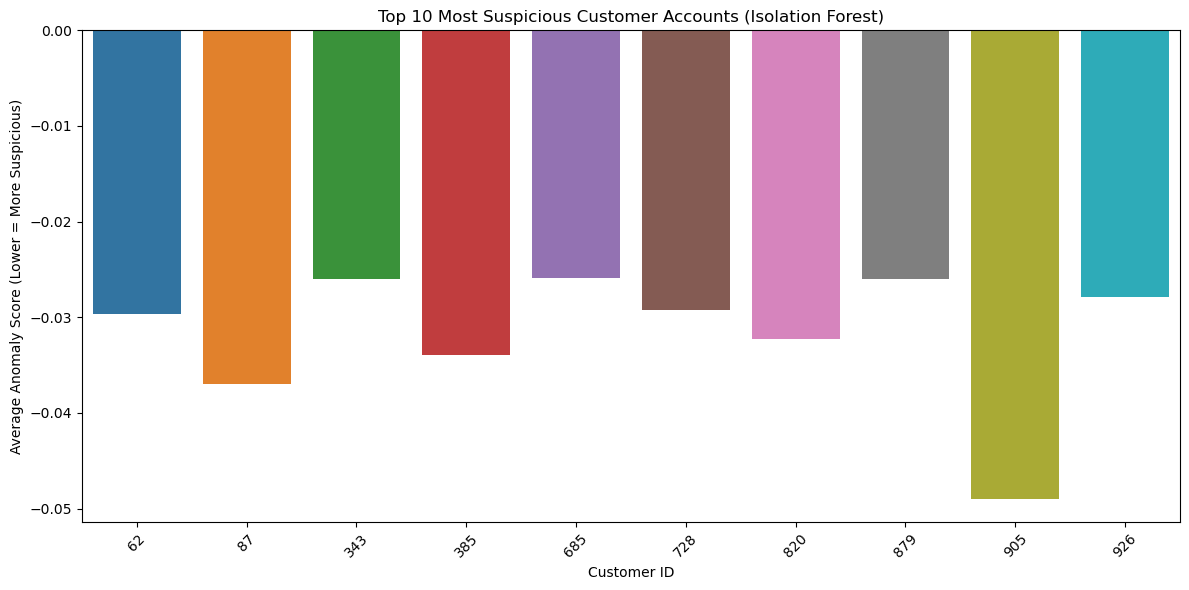

In [41]:
plt.figure(figsize=(12,6))
sns.barplot(x=top10_accounts.index, y=top10_accounts.values)

plt.title("Top 10 Most Suspicious Customer Accounts (Isolation Forest)")
plt.xlabel("Customer ID")
plt.ylabel("Average Anomaly Score (Lower = More Suspicious)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### The diagram displays the accounts with the highest anomaly scores. Among them, customer_id 905 exhibits the most suspicious behavior, followed by customer_id 87, 858, 258, 926, and others.

### Conclusion :
#### In this lab, we analyzed a dataset containing customer information and their transactions. Various operations were performed to extract insights, generate decisions, and support further data-driven decision-making processes.